# Import packages

In [1]:
# import packages

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder, OneHotEncoder
#import keras
#from keras.layers import Input, Dense
#from keras.models import Model
#import tensorflow as tf
#from keras.callbacks import History
#from keras.callbacks import CSVLogger
from sklearn.model_selection import train_test_split

# Functions

In [2]:
def help_adding_year(yr):
    """
    Update year string by adding one and return string.
    Args:
        yr (str): year
    """
    assert len(yr) == 4, 'year string is not correct length!'
    newyr = int(yr) + 1
    newyr = str(newyr)
    newyr = newyr.zfill(4)
    return newyr


def convert_mo_str(mo):
    """
    Convert integer month to two-digit month string.
    Args:
        mo (int): month
    """
    assert type(mo) is int, 'not an integer'
    return str(mo).zfill(2)


def help_updating_time(mo, yr):
    """
    Updating the month and year in cftime due to february start in cesm.
    Year and month (if december) are fixed.
    Args:
        mo (str): xarray filename
        yr (str): xarray filename
    """
    newmo = int(mo) + 1
    if newmo == 13:
        yr = help_adding_year(yr)
        newmo = 1
    assert newmo <= 12, 'month is greater than 12, there is an error!'
    newmo = convert_mo_str(newmo)
    return newmo, yr


def fixtime(ds):
    """
    Open file and add time coordinate.
    Args:
        ds (xarray dataset)
    """
    # start date range preprocessing
    mo0 = ds.encoding['source'].split('/')[-1].split('.')[-2][4:6]
    yr0 = ds.encoding['source'].split('/')[-1].split('.')[-2][:4]
    nm0, ny0 = help_updating_time(mo0, yr0)
    # end date range preprocessing
    yr1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-6:-2]
    mo1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-2:]
    nm1, ny1 = help_updating_time(mo1, yr1)
    # create datetime array in cftime
    newtime = xr.cftime_range(
        start=ny0+'-'+nm0+'-01',
        end=ny1+'-'+nm1+'-01',
        freq='MS',
        calendar='noleap'
    )
    ds = ds.assign_coords(time=newtime)
    return ds

## dask cluster

In [3]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=1,
        memory='15GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=30GB',
        project='UMCP0030',
        walltime='06:00:00')
        #interface='ib0',)

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [4]:
cluster, client = get_ClusterClient()
#cluster.scale(20) 
cluster.adapt(minimum=0, maximum=50)

In [5]:
cluster

AttributeError: 'Tab' object has no attribute '_ipython_display_'

Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.14.4.35:36397,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [1]:
# Close out Dask Cluster and release workers:
# NOTE:  only run this cell to terminate Dask Cluster!
cluster.close()
client.close()

NameError: name 'cluster' is not defined

# Use open_mfdataset on files without time issue

In [3]:
# combine piControl 1 year runs (50 files) into a single 500 year file
# do for various monthly ocean and atmosphere variables
ds_temp_ocn = xr.open_mfdataset(
    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/ocn/proc/tseries/month_1/v2.FV1.piControl.mpaso.hist.am.timeMonthly_avg_activeTracers_temperature.*.nc'
)

In [4]:
# print variables to check dimensions
ds_temp_ocn

<xarray.Dataset> Size: 96GB
Dimensions:                                    (time: 6000, lat: 180, nbnd: 2,
                                                lon: 360, nVertLevels: 60)
Coordinates:
  * lat                                        (lat) float64 1kB -89.5 ... 89.5
  * lon                                        (lon) float64 3kB 0.5 ... 359.5
  * time                                       (time) object 48kB 0001-02-01 ...
Dimensions without coordinates: nbnd, nVertLevels
Data variables:
    lat_bnds                                   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds                                   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                                         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                                       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_activeTracers_temperature  (time, nVertLevels, lat, lon) float32 93GB dask.array<chunksize=(120, 60, 180, 360), meta=np.ndarray>
    time_bnds                                  (time, nbnd) object 96kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes: (12/756)
    title:                                                        MPAS-Ocean ...
    source:                                                       CAM
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         b.e21.B1850...
    ...                                                           ...
    host:                                                         cheyenne4
    initial_file:                                                 b.e20.B1850...
    topography_file:                                              /glade/p/ce...
    model_doi_url:                                                https://doi...
    time_period_freq:                                             month_1
    history_of_appended_files:                                    Fri Apr 28 ...

# Handle files without time coordinate

In [5]:
# utilize functions to process sea surface heights 

#ds_ssh = xr.open_mfdataset(
#    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/ocn/proc/tseries/month_1/v2.FV1.piControl.mpaso.hist.am.timeMonthly_avg_ssh.*.nc',
#    preprocess=fixtime,
#    concat_dim='time',
#    combine='nested'
#)

In [6]:
# check file
#ds_ssh

## fix start time 

In [7]:
ds_temp_ocn = ds_temp_ocn.assign_coords(time=ds_temp_ocn['time'] - 
                                        xr.coding.cftime_offsets.MonthBegin(1))
#ds_ssh = ds_ssh.assign_coords(time=ds_ssh['time'] - xr.coding.cftime_offsets.MonthBegin(1))

In [8]:
ds_temp_ocn

<xarray.Dataset> Size: 96GB
Dimensions:                                    (time: 6000, lat: 180, nbnd: 2,
                                                lon: 360, nVertLevels: 60)
Coordinates:
  * lat                                        (lat) float64 1kB -89.5 ... 89.5
  * lon                                        (lon) float64 3kB 0.5 ... 359.5
  * time                                       (time) object 48kB 0001-01-01 ...
Dimensions without coordinates: nbnd, nVertLevels
Data variables:
    lat_bnds                                   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds                                   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                                         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                                       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_activeTracers_temperature  (time, nVertLevels, lat, lon) float32 93GB dask.array<chunksize=(120, 60, 180, 360), meta=np.ndarray>
    time_bnds                                  (time, nbnd) object 96kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes: (12/756)
    title:                                                        MPAS-Ocean ...
    source:                                                       CAM
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         b.e21.B1850...
    ...                                                           ...
    host:                                                         cheyenne4
    initial_file:                                                 b.e20.B1850...
    topography_file:                                              /glade/p/ce...
    model_doi_url:                                                https://doi...
    time_period_freq:                                             month_1
    history_of_appended_files:                                    Fri Apr 28 ...

In [9]:
#ds_ssh

In [10]:
print(ds_temp_ocn['timeMonthly_avg_activeTracers_temperature'].shape) 
      #ds_ssh['timeMonthly_avg_ssh'].shape)

(6000, 60, 180, 360)


# Slice files to Tropical Pacific Region

In [11]:
temp = ds_temp_ocn['timeMonthly_avg_activeTracers_temperature']

In [12]:
#ssh = ds_ssh['timeMonthly_avg_ssh']

In [13]:
temp

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               nVertLevels: 60,
                                                               lat: 180,
                                                               lon: 360)> Size: 93GB
dask.array<concatenate, shape=(6000, 60, 180, 360), dtype=float32, chunksize=(120, 60, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
Dimensions without coordinates: nVertLevels
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

In [14]:
# new spatial bounds
temp_tp = temp.sel(lat=slice(-10, 10), lon=slice(130, 280))
#ssh_tp = ssh.sel(lat=slice(-10, 10), lon=slice(130, 280))

In [15]:
# only want surface temp!
temp_tp = temp_tp[:,0]

In [16]:
temp_tp.shape

(6000, 20, 150)

In [17]:
# check file
# ssh_tp

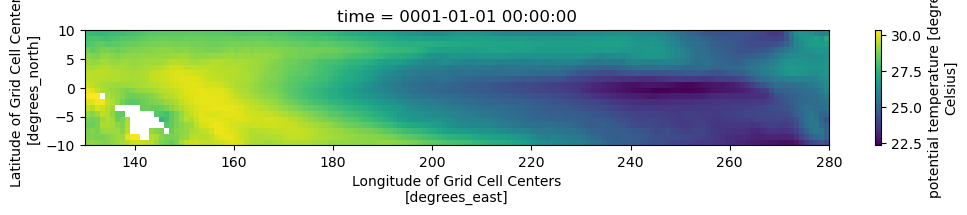

In [18]:
# plot using .pcolormesh() to for sanity check that slice was to tropical pacific region
temp_tp[0].plot.pcolormesh(figsize=(12, 1.5))

In [19]:
# plot using .pcolormesh() to for sanity check that slice was to tropical pacific region
#ssh_tp[0].plot.pcolormesh(figsize=(12, 1.5))

In [20]:
# check shapes
print(temp_tp.shape)
      #, ssh_tp.shape)

(6000, 20, 150)


## check if nan in sst dataset

In [21]:
# Check if there are any NaN values in the sst dataset
has_nan = temp_tp.isnull().any()

print(f"sst dataset contains NaN values: {has_nan.values}")

sst dataset contains NaN values: True


In [22]:
# Count the number of NaN values in the SSH dataset
#nan_count = temp_tp.isnull().sum()
#print(f"Number of NaN values in sst dataset: {nan_count.values}")

## climatology

In [23]:
sst_climo = temp_tp.groupby('time.month').mean(dim='time', keep_attrs=True)

In [24]:
sst_climo

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (month: 12,
                                                               lat: 20, lon: 150)> Size: 144kB
dask.array<stack, shape=(12, 20, 150), dtype=float32, chunksize=(1, 20, 150), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 160B -9.5 -8.5 -7.5 -6.5 -5.5 ... 5.5 6.5 7.5 8.5 9.5
  * lon      (lon) float64 1kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

In [25]:
sst_anom = temp_tp.groupby('time.month') - sst_climo

/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/xarray/core/indexing.py:1621: PerformanceWarning: Slicing with an out-of-order index is generating 500 times more chunks
  return self.array[key]


In [26]:
sst_anom

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               lat: 20, lon: 150)> Size: 72MB
dask.array<sub, shape=(6000, 20, 150), dtype=float32, chunksize=(1, 20, 150), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 160B -9.5 -8.5 -7.5 -6.5 -5.5 ... 5.5 6.5 7.5 8.5 9.5
  * lon      (lon) float64 1kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

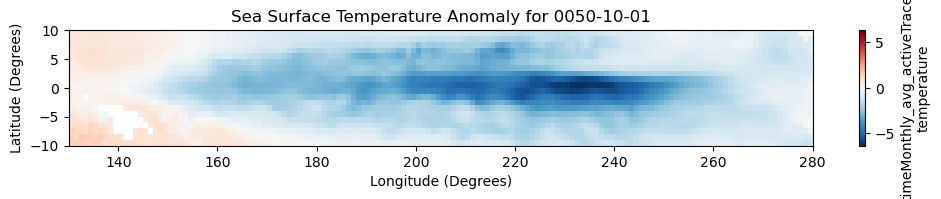

In [27]:
sst_anom[597].plot.pcolormesh(figsize=(12, 1.5), cmap='RdBu_r')
plt.title('Sea Surface Temperature Anomaly for 0050-10-01')
plt.xlabel('Longitude (Degrees)')
plt.ylabel('Latitude (Degrees)')

#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/agufigs/sstinput.pdf', bbox_inches='tight')
plt.show()

## how to do grid reconstruction [from Maria]

In [28]:
def create_index_mask(da):
    """
    Create index mask for reconstruction of predictions.
    Args:
        da (xarray data array): 2d input variable samples
    Returns:
        y_, x_ (numpy arrays): x and y indices for reconstruction
    """
    # just one sample needed; time=0
    da = da.isel(time=0)
    
    # original 2d grid shape
    orig_2d_shape = da.shape
    
    # location of the valid values (not nan) in 1d vector
    orig_indx = np.where(~np.isnan(da.stack(newdim=['lat', 'lon']).values))[0]
    
    # Indices of non-nan values in original 2d grid
    y_, x_ = np.unravel_index(orig_indx, orig_2d_shape)
    
    # return the respective indices for (20, 150)
    return y_, x_

def reconstruct_grid(pred_1d, y_indx, x_indx):
    """
    Reconstruct the original 2d grid using NN predictions.
    Args:
        pred_1d (xarray data array): predictions (samples, 1d values)
        y_indx (numpy array): latitude indices for grid (20)
        x_indx (numpy array): longitude indices for grid (150)
    Returns:
        pred_grid (numpy array): predictions on original 2d grid
    """
    # number of predicted samples (!assuming axis=0!)
    n_samples = pred_1d.shape[0]
    
    # grid to be populated with predicted data
    pred_grid = np.full((n_samples, 20, 150), np.nan)
    
    # fill the reconstructed grid
    pred_grid[:, y_indx, x_indx] = pred_1d.values
    
    # return predictions on original 2d grid
    return pred_grid

In [29]:
# produce the indices to be used
y_vals, x_vals = create_index_mask(sst_anom)

# save the numpy arrays of the y, x indices
np.save('sst_yindx.npy', y_vals)
np.save('sst_xindx.npy', x_vals)

In [30]:
# indices can be loaded anytime and used for reconstruction
yindx = np.load('sst_yindx.npy')
xindx = np.load('sst_xindx.npy')

### fake predictions here just using actual data
# flattened grid shape
sst_newdim = sst_anom.stack(newdim=['lat', 'lon'])
# flattened grid shape after dropping nans
sst_processed = sst_newdim.dropna('newdim', how='any')

# now reconstruct fake predictions
predictions_2d = reconstruct_grid(sst_processed, yindx, xindx)

# can close files like this
del yindx
del xindx

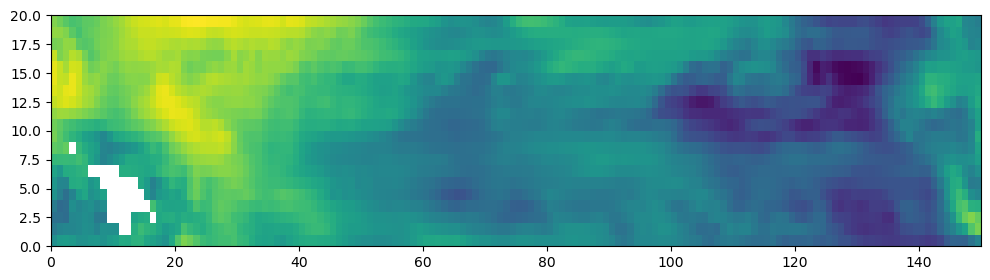

In [31]:
# quick viz of reconstruction
plt.figure(figsize=(12,3))
plt.pcolormesh(predictions_2d[0,:,:])
plt.show()

## stack dims

In [34]:
sst_newdim = sst_anom.stack(newdim=['lat', 'lon'])

In [35]:
sst_newdim.shape

(6000, 3000)

In [36]:
sst_newdim

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               newdim: 3000)> Size: 72MB
dask.array<reshape, shape=(6000, 3000), dtype=float32, chunksize=(1, 3000), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [37]:
sst_processed = sst_newdim.dropna('newdim', how='all')
sst_processed = sst_newdim.dropna('newdim', how='any')

In [38]:
sst_processed

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               newdim: 2968)> Size: 71MB
dask.array<getitem, shape=(6000, 2968), dtype=float32, chunksize=(1, 2968), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [39]:
sst_processed.shape

(6000, 2968)

In [40]:
has_nan = sst_processed.isnull().any().compute().item()
print(has_nan)

False


# Split into test and train 

In [41]:
sst_train, sst_test = train_test_split(
    sst_processed, test_size=0.2, random_state=0, shuffle=True
)

In [42]:
# check shapes of train and test data 
print(sst_train.shape, 
      sst_test.shape)

(4800, 2968) (1200, 2968)


## RobustScaler()

In [43]:
from sklearn.preprocessing import RobustScaler

sst_train_tmp = sst_train.copy()
sst_train_tmp = sst_train_tmp.values

scaler_tmp = RobustScaler()
scaler_tmp_sst = scaler_tmp.fit(sst_train_tmp.reshape(4800 * 2968, 1))

In [44]:
scaler = RobustScaler()

scaler_sst = scaler.fit(sst_train)

In [45]:
scaler_sst.center_ = np.repeat(scaler_tmp_sst.center_, 2968)

In [46]:
scaler_sst.scale_ = np.repeat(scaler_tmp_sst.scale_, 2968)

In [47]:
scaled_input_sst_train = scaler_sst.transform(sst_train)

scaled_input_sst_test = scaler_sst.transform(sst_test)

print(scaled_input_sst_train.shape, scaled_input_sst_test.shape)

(4800, 2968) (1200, 2968)


In [48]:
import joblib

# Save the scaler to a file
joblib.dump(scaler_sst, 'scaler_sst.pkl')

print("Scaler saved successfully!")

Scaler saved successfully!


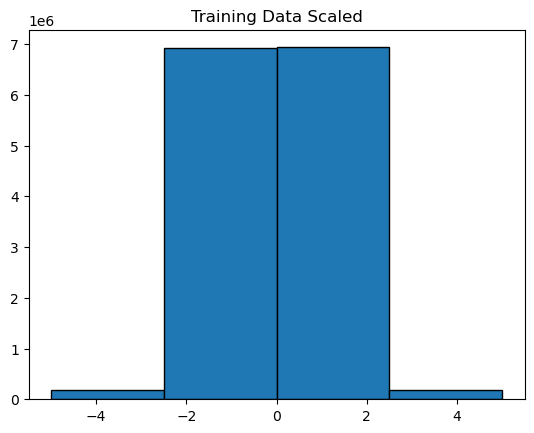

In [49]:
plt.hist(scaled_input_sst_train.flatten(), bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('Training Data Scaled')
plt.show()

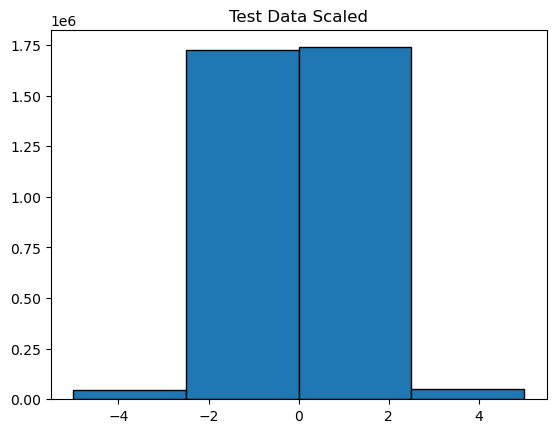

In [50]:
plt.hist(scaled_input_sst_test.flatten(), bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('Test Data Scaled')
plt.show()

## RETAIN TIME COMPONENT FOR SORTING LATER ON

In [51]:
scaled_input_sst_train.shape

(4800, 2968)

In [52]:
scaled_input_sst_test.shape

(1200, 2968)

In [53]:
import xarray as xr

# Get original coordinates for each dimension
coords = sst_train.coords  # Retains 'time', 'lat', 'lon', etc.
dims = sst_train.dims      # Keeps the dimensions as ('newdim',)

# Create a new DataArray with the scaled data and the original coordinates
sst_train_coords = xr.DataArray(scaled_input_sst_train, dims=dims, coords=coords)

In [54]:
sst_train_coords

<xarray.DataArray (time: 4800, newdim: 2968)> Size: 57MB
array([[-0.07861855, -0.14215587, -0.19736274, ..., -0.10560908,
        -0.13798559, -0.16396768],
       [-0.08183599, -0.04659336, -0.07935404, ..., -0.1433286 ,
        -0.1426007 , -0.21731941],
       [-0.6227208 , -0.7048019 , -0.53963375, ..., -0.06147998,
        -0.0683066 , -0.07550474],
       ...,
       [ 0.10856619,  0.20029962,  0.32955796, ...,  0.2720966 ,
         0.37365422,  0.38912216],
       [-0.7562657 , -0.7464516 , -0.6627403 , ..., -0.06114889,
        -0.05420854, -0.13564518],
       [-0.11224867, -0.02304267,  0.20995192, ...,  0.26840404,
         0.3020771 ,  0.39176837]], dtype=float32)
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [55]:
# Get original coordinates for each dimension
coords = sst_test.coords  # Retains 'time', 'lat', 'lon', etc.
dims = sst_test.dims      # Keeps the dimensions as ('newdim',)

# Create a new DataArray with the scaled data and the original coordinates
sst_test_coords = xr.DataArray(scaled_input_sst_test, dims=dims, coords=coords)

In [56]:
sst_test_coords

<xarray.DataArray (time: 1200, newdim: 2968)> Size: 14MB
array([[-0.46359065, -0.60571617, -0.77645487, ...,  0.09887093,
         0.07388971,  0.01491442],
       [-0.37649506, -0.3998309 , -0.54369783, ..., -0.11884276,
        -0.1317959 , -0.10782312],
       [ 0.24239667,  0.18229668,  0.16628028, ..., -0.19123118,
        -0.21989487, -0.2408524 ],
       ...,
       [ 0.3562983 ,  0.39527646,  0.49703625, ...,  0.06569828,
         0.08118138, -0.0373126 ],
       [ 0.35452402,  0.39845094,  0.45944312, ..., -0.24596794,
        -0.1585084 , -0.07985194],
       [ 0.23833507,  0.24282634,  0.26705185, ...,  0.36038768,
         0.36764395,  0.30015373]], dtype=float32)
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [57]:
print(sst_train_coords.shape, sst_test_coords.shape)

(4800, 2968) (1200, 2968)


In [58]:
# Convert MultiIndex levels in `newdim` into separate coordinates
sst_train_reset_index = sst_train_coords.reset_index('newdim')

In [59]:
sst_train_reset_index

<xarray.DataArray (time: 4800, newdim: 2968)> Size: 57MB
array([[-0.07861855, -0.14215587, -0.19736274, ..., -0.10560908,
        -0.13798559, -0.16396768],
       [-0.08183599, -0.04659336, -0.07935404, ..., -0.1433286 ,
        -0.1426007 , -0.21731941],
       [-0.6227208 , -0.7048019 , -0.53963375, ..., -0.06147998,
        -0.0683066 , -0.07550474],
       ...,
       [ 0.10856619,  0.20029962,  0.32955796, ...,  0.2720966 ,
         0.37365422,  0.38912216],
       [-0.7562657 , -0.7464516 , -0.6627403 , ..., -0.06114889,
        -0.05420854, -0.13564518],
       [-0.11224867, -0.02304267,  0.20995192, ...,  0.26840404,
         0.3020771 ,  0.39176837]], dtype=float32)
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [60]:
# Convert MultiIndex levels in `newdim` into separate coordinates
sst_test_reset_index = sst_test_coords.reset_index('newdim')

In [61]:
sst_test_reset_index

<xarray.DataArray (time: 1200, newdim: 2968)> Size: 14MB
array([[-0.46359065, -0.60571617, -0.77645487, ...,  0.09887093,
         0.07388971,  0.01491442],
       [-0.37649506, -0.3998309 , -0.54369783, ..., -0.11884276,
        -0.1317959 , -0.10782312],
       [ 0.24239667,  0.18229668,  0.16628028, ..., -0.19123118,
        -0.21989487, -0.2408524 ],
       ...,
       [ 0.3562983 ,  0.39527646,  0.49703625, ...,  0.06569828,
         0.08118138, -0.0373126 ],
       [ 0.35452402,  0.39845094,  0.45944312, ..., -0.24596794,
        -0.1585084 , -0.07985194],
       [ 0.23833507,  0.24282634,  0.26705185, ...,  0.36038768,
         0.36764395,  0.30015373]], dtype=float32)
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [62]:
# Save the xarray DataArray to a NetCDF file
sst_train = sst_train_reset_index.to_netcdf('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_train_robustscaler.nc')
sst_test = sst_test_reset_index.to_netcdf('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_test_robustscaler.nc')

# Save out file

In [65]:
from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt

In [66]:
# sst train and test
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_train_robustscaler.csv',
        scaled_input_sst_train, delimiter=',')
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_test_robustscaler.csv',
        scaled_input_sst_test, delimiter=',')

In [137]:
# csv to numpy array
# sst train and test
#scaled_input_sst_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/scaleddata/sst_train_0902.csv', delimiter=',')
#scaled_input_sst_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/scaleddata/sst_test_0902.csv', delimiter=',')
oni_e3sm = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/scaleddata/oni_e3sm.csv', delimiter=',')

In [7]:
oni_e3sm = oni_e3sm[~np.isnan(oni_e3sm)]

In [8]:
oni_e3sm

array([-0.54011178, -0.42085293, -0.2258876 , ..., -2.11957908,
       -2.29146361, -2.4201982 ])

In [9]:
oni_e3sm.shape

(5998,)

In [10]:
scaled_input_sst_train[:10]

array([[-0.1805539 , -0.5370841 , -0.56138921, ..., -1.35928369,
        -1.49945867, -1.36141264],
       [ 0.09710305,  0.33623269,  0.50245595, ..., -0.94637215,
        -1.11764491, -0.84634554],
       [ 1.01250839,  0.94289333,  0.89043462, ..., -0.54636049,
        -0.61909479, -0.68984663],
       ...,
       [-0.22362885, -0.57767814, -0.71598625, ..., -1.32835305,
        -0.92774284, -0.92781603],
       [-0.4161284 , -0.40593353, -0.45849565, ..., -2.57175636,
        -2.29779553, -1.98955238],
       [-0.32029504,  0.08013088,  0.42057401, ..., -1.3646847 ,
        -1.11088598, -1.68003011]])

In [11]:
scaled_input_sst_test[:10]

array([[ 8.70385170e-01,  1.31379890e+00,  1.29523432e+00, ...,
        -3.41447085e-01, -5.23473024e-01, -4.45805997e-01],
       [ 5.18532060e-02,  3.27976508e-04, -5.10450453e-02, ...,
        -3.30723137e-01, -5.70255935e-01, -1.11579347e+00],
       [ 7.75065362e-01,  7.99491346e-01,  9.60824490e-01, ...,
        -1.24800897e+00, -1.26823223e+00, -1.33172655e+00],
       ...,
       [ 3.32297802e-01,  1.31236091e-01,  7.49711543e-02, ...,
        -1.77764821e+00, -1.35683811e+00, -9.98061538e-01],
       [ 6.52887285e-01,  1.77986220e-01,  9.91871879e-02, ...,
        -2.11265659e+00, -1.80794215e+00, -1.17425764e+00],
       [ 6.30417764e-01,  2.08757564e-01,  6.00068383e-02, ...,
        -7.03210831e-01, -1.04111767e+00, -7.52760947e-01]])

In [8]:
import numpy as np
np.mean(scaled_input_sst_train, axis=1).mean()

-1.5926454821624248e-10

In [9]:
np.mean(scaled_input_sst_test, axis=1).mean()

-0.03853275139332666

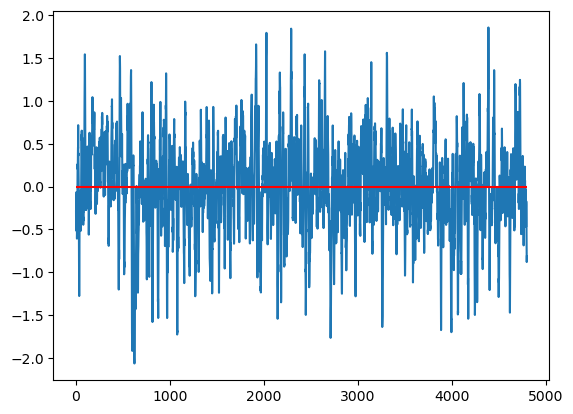

In [9]:
import matplotlib.pyplot as plt
plt.plot(np.mean(scaled_input_sst_train, axis=1))
plt.hlines(np.mean(scaled_input_sst_train, axis=1).mean(), 0, 4800, colors='r')
plt.show()

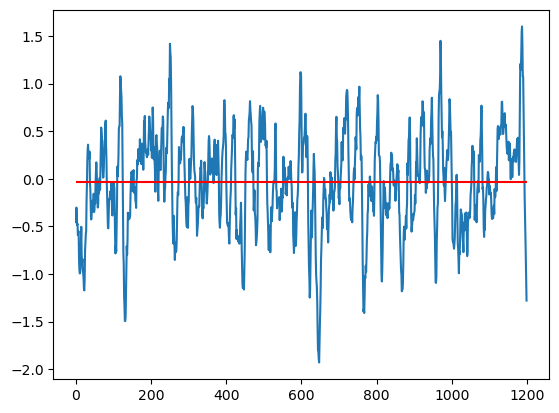

In [10]:
plt.plot(np.mean(scaled_input_sst_test, axis=1))
plt.hlines(np.mean(scaled_input_sst_test, axis=1).mean(), 0, 1200, colors='r')
plt.show()

In [13]:
scaled_input_sst_test

array([[ 8.70385170e-01,  1.31379890e+00,  1.29523432e+00, ...,
        -3.41447085e-01, -5.23473024e-01, -4.45805997e-01],
       [ 5.18532060e-02,  3.27976508e-04, -5.10450453e-02, ...,
        -3.30723137e-01, -5.70255935e-01, -1.11579347e+00],
       [ 7.75065362e-01,  7.99491346e-01,  9.60824490e-01, ...,
        -1.24800897e+00, -1.26823223e+00, -1.33172655e+00],
       ...,
       [ 2.57406831e+00,  2.23577046e+00,  1.97567976e+00, ...,
         3.21600288e-01, -4.19838220e-01, -3.18983734e-01],
       [ 1.20972884e+00,  9.72993612e-01,  8.10819864e-01, ...,
        -4.10173953e-01, -6.30495012e-01, -1.59573543e+00],
       [-1.52075362e+00, -1.31550241e+00, -1.37122488e+00, ...,
        -1.12529874e+00, -9.13423181e-01, -1.16261423e+00]])

In [170]:
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/csv_10s10n/sst_train_0825.csv',
        sst_train_final_numpy, delimiter=',')
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/csv_10s10n/sst_test_0825.csv',
        sst_test_final_numpy, delimiter=',')

# Build autoencoder

In [24]:
# set random seed
# tf.random.set_seed(1)
keras.utils.set_random_seed(1)

In [25]:
# check input shape for sst
input_shape_sst = scaled_input_sst_train.shape[1]
print(input_shape_sst)

3207


In [26]:
type(np.int64(input_shape_sst),)

numpy.int64

In [27]:
np.int64(input_shape_sst).dtype

dtype('int64')

In [28]:
# sst input

#enso_model = Model(inputs=[input_sst, input_ssh, input_zonalstress],
#                   outputs=[output_sst, output_ssh, output_zonalstress])

input_sst_1 = Input(shape=(np.int64(input_shape_sst),), name='input_sst_1')
print(input_sst_1.shape)

# add 2 dense layers
encoded_sst_1_layer1 = Dense(50, activation='tanh')(input_sst_1)
encoded_sst_1_layer2 = Dense(10, activation='tanh')(encoded_sst_1_layer1)

# ssh input
input_sst_2 = Input(shape=(np.int64(input_shape_sst),), name='input_sst_2')
print(input_sst_2.shape)

# add 2 dense layers (again)
encoded_sst_2_layer1 = Dense(50, activation='tanh')(input_sst_2)
encoded_sst_2_layer2 = Dense(10, activation='tanh')(encoded_sst_2_layer1)

# zonal stress input 
# ssh input
input_sst_3 = Input(shape=(np.int64(input_shape_sst),),
                          name='input_sst_3')
print(input_sst_3.shape)

# add 2 dense layers (again)
encoded_sst_3_layer1 = Dense(50, activation='tanh')(input_sst_3)
encoded_sst_3_layer2 = Dense(10, activation='tanh')(encoded_sst_3_layer1)

(None, 3207)
(None, 3207)
(None, 3207)


In [29]:
# add concatenation layer
# merge 3 input fields

bottleneck = keras.layers.concatenate(
    [encoded_sst_1_layer2, encoded_sst_2_layer2, encoded_sst_3_layer2])
bottleneck1 = Dense(1, activation='tanh')(bottleneck)
print(bottleneck1)

# build decoder for each variable from the bottleneck
# sst
decoded1_sst_1 = Dense(10, activation='tanh')(bottleneck1)
decoded2_sst_1 = Dense(50, activation='tanh')(decoded1_sst_1)
output_sst_1 = Dense(np.int64(input_shape_sst), activation='linear', name='output_sst_1')(decoded2_sst_1)
print(output_sst_1.shape)

# build decoder for each variable from the bottleneck
# ssh
decoded1_sst_2 = Dense(10, activation='tanh')(bottleneck1)
decoded2_sst_2 = Dense(50, activation='tanh')(decoded1_sst_2)
output_sst_2 = Dense(np.int64(input_shape_sst), activation='linear', name='output_sst_2')(decoded2_sst_2)
print(output_sst_2.shape)

# build decoder for each variable from the bottleneck
# zonal stress
decoded1_sst_3 = Dense(10, activation='tanh')(bottleneck1)
decoded2_sst_3 = Dense(50, activation='tanh')(decoded1_sst_3)
output_sst_3 = Dense(
    np.int64(input_shape_sst), activation='linear', name='output_sst_3')(decoded2_sst_3)
print(output_sst_3.shape)

KerasTensor(type_spec=TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), name='dense_19/Tanh:0', description="created by layer 'dense_19'")
(None, 3207)
(None, 3207)
(None, 3207)


In [30]:
# only using lists
# maps inputs to outputs
enso_model = Model(inputs=[input_sst_1, input_sst_2, input_sst_3],
                   outputs=[output_sst_1, output_sst_2, output_sst_3])

# ompile the model using lists
enso_model.compile(optimizer='adam',
                   loss='mean_squared_error',
                   metrics=['accuracy']
                  )

In [31]:
enso_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_sst_1 (InputLayer)    [(None, 3207)]               0         []                            
                                                                                                  
 input_sst_2 (InputLayer)    [(None, 3207)]               0         []                            
                                                                                                  
 input_sst_3 (InputLayer)    [(None, 3207)]               0         []                            
                                                                                                  
 dense_13 (Dense)            (None, 50)                   160400    ['input_sst_1[0][0]']         
                                                                                            

In [32]:
# train the model!
enso_model_history = enso_model.fit(x=[scaled_input_sst_train,
                                       scaled_input_sst_train,
                                       scaled_input_sst_train],
                                    y=[scaled_input_sst_train,
                                       scaled_input_sst_train,
                                       scaled_input_sst_train],
                                    epochs=500,
                                    batch_size=32,
                                    validation_split=0.2
                                   )

Epoch 1/500
120/120 [==============================] - 3s 10ms/step - loss: 2.2055 - output_sst_1_loss: 0.7387 - output_sst_2_loss: 0.7335 - output_sst_3_loss: 0.7333 - output_sst_1_accuracy: 7.8125e-04 - output_sst_2_accuracy: 7.8125e-04 - output_sst_3_accuracy: 0.0010 - val_loss: 1.9509 - val_output_sst_1_loss: 0.6492 - val_output_sst_2_loss: 0.6506 - val_output_sst_3_loss: 0.6512 - val_output_sst_1_accuracy: 0.0000e+00 - val_output_sst_2_accuracy: 0.0000e+00 - val_output_sst_3_accuracy: 0.0000e+00
Epoch 2/500
120/120 [==============================] - 1s 7ms/step - loss: 1.8997 - output_sst_1_loss: 0.6323 - output_sst_2_loss: 0.6335 - output_sst_3_loss: 0.6339 - output_sst_1_accuracy: 2.6042e-04 - output_sst_2_accuracy: 2.6042e-04 - output_sst_3_accuracy: 2.6042e-04 - val_loss: 1.9150 - val_output_sst_1_loss: 0.6377 - val_output_sst_2_loss: 0.6385 - val_output_sst_3_loss: 0.6389 - val_output_sst_1_accuracy: 0.0000e+00 - val_output_sst_2_accuracy: 0.0000e+00 - val_output_sst_3_accura

In [33]:
from keras.callbacks import History
tf.keras.callbacks.History()

# print dictionary keys
print(enso_model_history.history.keys())

# print model parameters
print(enso_model_history.params)

dict_keys(['loss', 'output_sst_1_loss', 'output_sst_2_loss', 'output_sst_3_loss', 'output_sst_1_accuracy', 'output_sst_2_accuracy', 'output_sst_3_accuracy', 'val_loss', 'val_output_sst_1_loss', 'val_output_sst_2_loss', 'val_output_sst_3_loss', 'val_output_sst_1_accuracy', 'val_output_sst_2_accuracy', 'val_output_sst_3_accuracy'])
{'verbose': 1, 'epochs': 500, 'steps': 120}


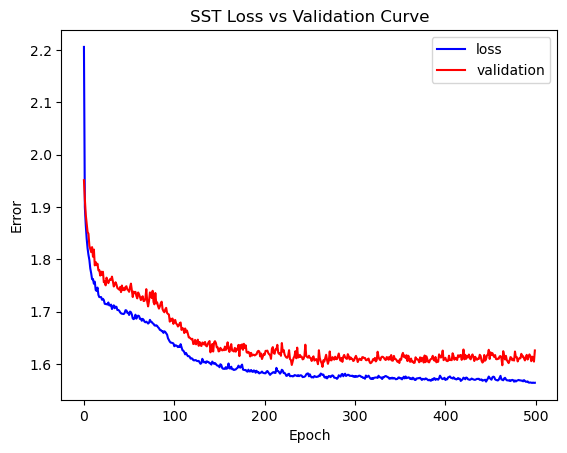

In [35]:
plt.plot(enso_model_history.history['loss'], label='loss', color='blue')
plt.plot(enso_model_history.history['val_loss'], label='validation', color='red')
plt.legend()
plt.title('SST Loss vs Validation Curve')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/figures/validloss_sst_0911.png', dpi=350, bbox_inches='tight')
plt.show()

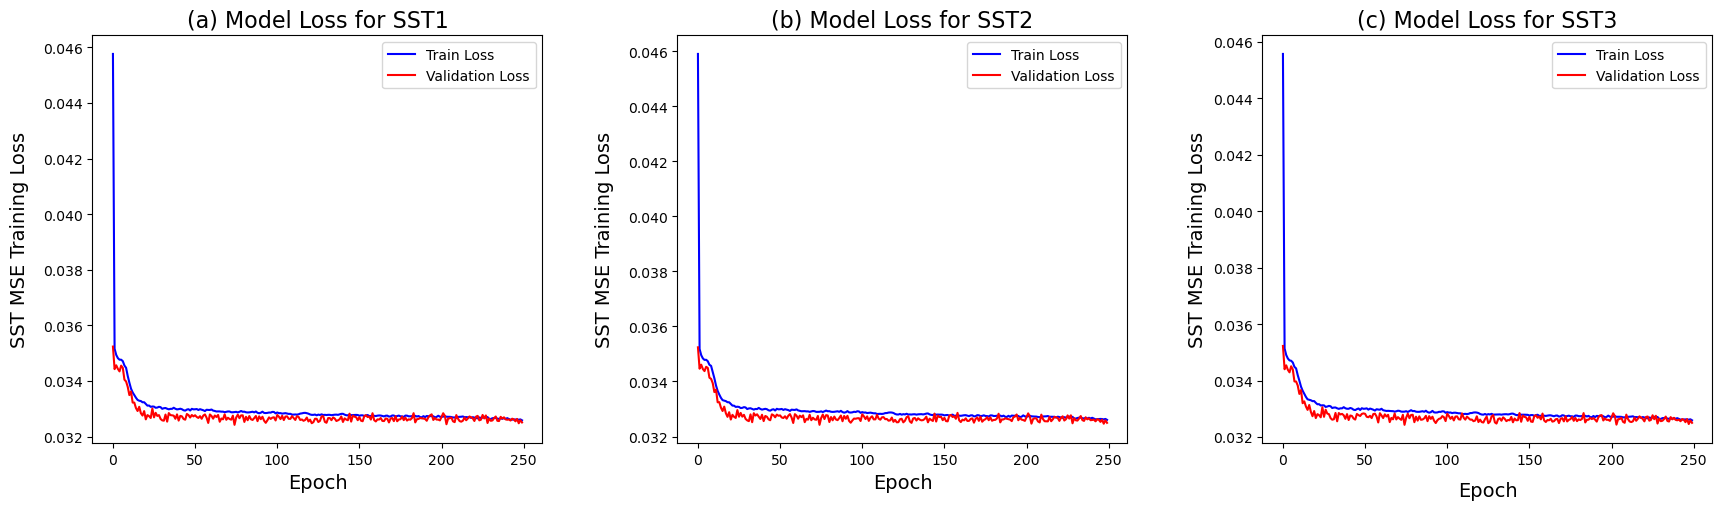

In [107]:
fig, (ax1_sstloss, ax2_sshloss, ax3_zonalstressloss) = plt.subplots(1, 3, figsize = (18,6))
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.20, wspace=0.30)
#plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.30, hspace=None)

ax1_sstloss.set_title('(a) Model Loss for SST1', fontsize=16)# pad=28)
ax1_sstloss.set_xlabel('Epoch', fontsize=14)#, labelpad=10)
ax1_sstloss.set_ylabel('SST MSE Training Loss', fontsize=14, labelpad=10)
ax1_sstloss.plot(enso_model_history.history['output_sst_1_loss'], color='blue', label='Train Loss')
ax1_sstloss.plot(enso_model_history.history['val_output_sst_1_loss'], color='red', label='Validation Loss')
ax1_sstloss.legend(loc='best')

ax2_sshloss.set_title('(b) Model Loss for SST2', fontsize=16)#, pad=28)
ax2_sshloss.set_xlabel('Epoch', fontsize=14)#, labelpad=10)
ax2_sshloss.set_ylabel('SST MSE Training Loss', fontsize=14, labelpad=10)
ax2_sshloss.plot(enso_model_history.history['output_sst_2_loss'], color='blue', label='Train Loss')
ax2_sshloss.plot(enso_model_history.history['val_output_sst_2_loss'], color='red', label='Validation Loss')
ax2_sshloss.legend(loc='best')

ax3_zonalstressloss.set_title('(c) Model Loss for SST3', fontsize=16)#, pad=28)
ax3_zonalstressloss.set_xlabel('Epoch', fontsize=14, labelpad=10)
ax3_zonalstressloss.set_ylabel('SST MSE Training Loss', fontsize=14)#, labelpad=10)
ax3_zonalstressloss.plot(enso_model_history.history['output_sst_3_loss'], color='blue', label='Train Loss')
ax3_zonalstressloss.plot(enso_model_history.history['val_output_sst_3_loss'], color='red', label='Validation Loss')
ax3_zonalstressloss.legend(loc='best')

#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/Figures/modelloss_350epochs_0810.png', dpi=350, bbox_inches='tight')
plt.show()

# Extract Bottleneck Layer (OLD KERAS METHOD)

In [108]:
# import any packages?

In [36]:
get_bottleneck = keras.backend.function([enso_model.layers[0].input,
                                      enso_model.layers[1].input,
                                      enso_model.layers[2].input],
                                     [enso_model.layers[10].output])

In [37]:
bottleneck_output = get_bottleneck([scaled_input_sst_train,
                                    scaled_input_sst_train,
                                    scaled_input_sst_train])

In [46]:
bottleneck_output[0]

array([[0.35890815],
       [0.37348142],
       [0.36062515],
       ...,
       [0.52780885],
       [0.5525924 ],
       [0.5251238 ]], dtype=float32)

In [39]:
bottleneck_output[0][:500:3].shape

(167, 1)

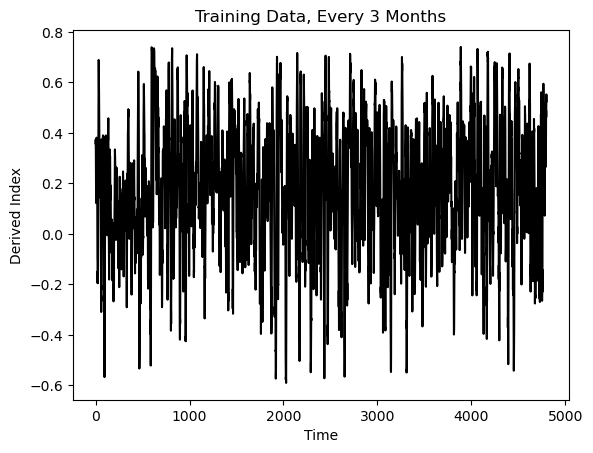

In [40]:
plt.plot(bottleneck_output[0], color='black')
plt.title('Training Data, Every 3 Months')
plt.xlabel('Time')
plt.ylabel('Derived Index')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/bottlenecktrain_sstonly_0810.png', dpi=350)
plt.show()

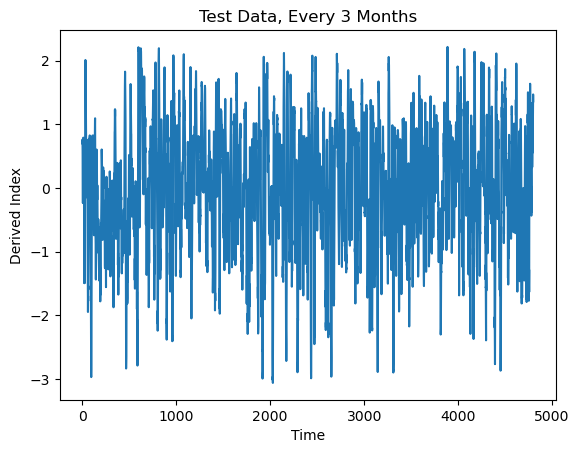

In [41]:
plt.plot(
    (bottleneck_output[0] - bottleneck_output[0].mean()) / bottleneck_output[0].std()
)
plt.title('Test Data, Every 3 Months')
plt.xlabel('Time')
plt.ylabel('Derived Index')
plt.show()

In [42]:
print(bottleneck_output[0].mean(), bottleneck_output[0].std())

0.18173777 0.25237846


In [44]:
bottleneck_train_scaled = ((bottleneck_output[0] - bottleneck_output[0].mean()) / bottleneck_output[0].std())

In [45]:
bottleneck_train_scaled

array([[0.70200276],
       [0.7597465 ],
       [0.70880604],
       ...,
       [1.3712385 ],
       [1.4694384 ],
       [1.3605994 ]], dtype=float32)

In [47]:
bottleneck_train_scaled.shape

(4800, 1)

In [48]:
print(bottleneck_train_scaled[0].mean(), bottleneck_train_scaled[0].std())

0.70200276 0.0


In [49]:
#bottleneck_train = bottleneck_output[0]
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/output_bottleneck/sst_troppac_train_0911.csv',
        bottleneck_train_scaled, delimiter=',')

In [50]:
bottleneck_output_test = get_bottleneck([scaled_input_sst_test,
                                         scaled_input_sst_test,
                                         scaled_input_sst_test])

In [51]:
bottleneck_output_test[0].shape

(1200, 1)

In [54]:
print(bottleneck_output_test[0].mean(), bottleneck_output_test[0].std())

0.19201101 0.2564733


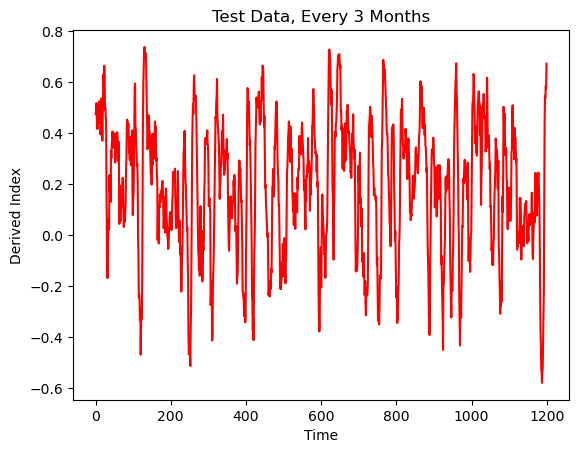

In [52]:
plt.plot(bottleneck_output_test[0], color='red')
plt.title('Test Data, Every 3 Months')
plt.xlabel('Time')
plt.ylabel('Derived Index')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/bottlenecktest_sstonly_0810.png', dpi=350)
plt.show()
#savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/testdata_0811.csv', MIMO_AE_index_test, delimiter=',')

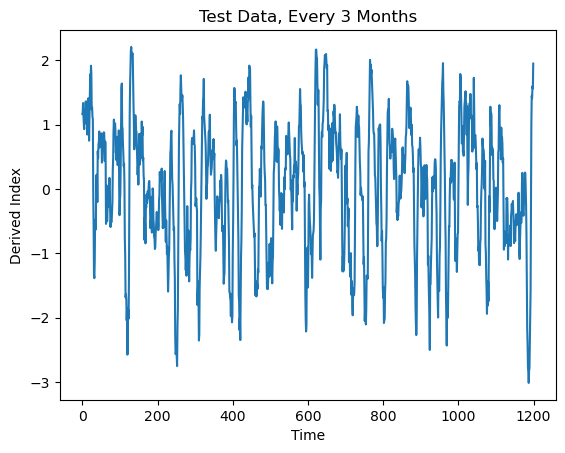

In [53]:
plt.plot(
    (bottleneck_output_test[0] - bottleneck_output[0].mean()) / bottleneck_output[0].std()
)
plt.title('Test Data, Every 3 Months')
plt.xlabel('Time')
plt.ylabel('Derived Index')
plt.show()

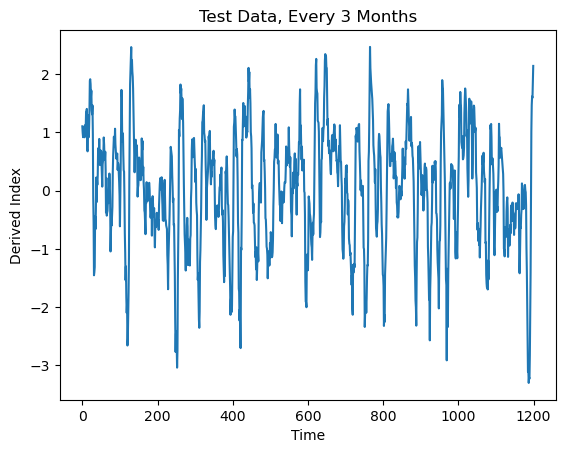

In [61]:
plt.plot(
    (bottleneck_output_test[0] - bottleneck_output[0].mean()) / bottleneck_output[0].std()
)
plt.title('Test Data, Every 3 Months')
plt.xlabel('Time')
plt.ylabel('Derived Index')
plt.show()

In [56]:
bottleneck_test_scaled = ((bottleneck_output_test[0] - bottleneck_output[0].mean()) / bottleneck_output[0].std())

In [57]:
bottleneck_test_scaled

array([[1.1657356],
       [1.1874259],
       [1.334736 ],
       ...,
       [1.5970292],
       [1.5610158],
       [1.9478859]], dtype=float32)

In [58]:
bottleneck_test_scaled.shape

(1200, 1)

In [59]:
print(bottleneck_test_scaled[0].mean(), bottleneck_test_scaled[0].std())

1.1657356 0.0


In [60]:
#bottleneck_test = bottleneck_output_test[0]
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/output_bottleneck/sst_troppac_test_0911.csv',
        bottleneck_test_scaled, delimiter=',')

# Stack Training and Test Data

In [113]:
training = pd.read_csv('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/output_bottleneck/sst_troppac_train_0911.csv',
                       engine='python', header=None)
test = pd.read_csv('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/output_bottleneck/sst_troppac_test_0911.csv',
                       engine='python', header=None)

In [114]:
training = training.values
test = test.values

In [115]:
training = training * -1

In [116]:
test = test * -1

In [117]:
ensomodel_train = training.astype('float32')
ensomodel_test = test.astype('float32')

In [118]:
print(ensomodel_train.shape, ensomodel_test.shape)

(4800, 1) (1200, 1)


In [119]:
ensomodel_train

array([[-0.70200276],
       [-0.7597465 ],
       [-0.70880604],
       ...,
       [-1.3712385 ],
       [-1.4694384 ],
       [-1.3605994 ]], dtype=float32)

In [120]:
ensomodel_test

array([[-1.1657356],
       [-1.1874259],
       [-1.334736 ],
       ...,
       [-1.5970292],
       [-1.5610158],
       [-1.9478859]], dtype=float32)

In [121]:
import pandas as pd

# Function to create a custom date string representation
def generate_custom_dates(start_year, start_month, periods):
    dates = []
    year, month = start_year, start_month
    for _ in range(periods):
        dates.append(f'{year:04d}-{month:02d}-01')
        month += 1
        if month > 12:
            month = 1
            year += 1
    return dates

# Create string representations of the train dates
ensomodel_train_index = pd.DataFrame(ensomodel_train)
train_dates = generate_custom_dates(start_year=1, start_month=2, periods=len(ensomodel_train_index))
ensomodel_train_index['date'] = train_dates
date_train = ensomodel_train_index['date']

# Create string representations of the test dates
ensomodel_test_index = pd.DataFrame(ensomodel_test)
test_dates = generate_custom_dates(start_year=401, start_month=2, periods=len(ensomodel_test_index))
ensomodel_test_index['date'] = test_dates
date_test = ensomodel_test_index['date']

In [122]:
ensomodel_train_index

,0,date
0,-0.702003,0001-02-01
1,-0.759746,0001-03-01
2,-0.708806,0001-04-01
3,-0.582079,0001-05-01
4,-0.237575,0001-06-01
...,...,...
4795,-1.213498,0400-09-01
4796,-1.111517,0400-10-01
4797,-1.371238,0400-11-01
4798,-1.469438,0400-12-01


In [123]:
ensomodel_test_index

,0,date
0,-1.165736,0401-02-01
1,-1.187426,0401-03-01
2,-1.334736,0401-04-01
3,-1.138483,0401-05-01
4,-1.013698,0401-06-01
...,...,...
1195,-1.448218,0500-09-01
1196,-1.408967,0500-10-01
1197,-1.597029,0500-11-01
1198,-1.561016,0500-12-01


In [124]:
date_train

0       0001-02-01
1       0001-03-01
2       0001-04-01
3       0001-05-01
4       0001-06-01
           ...    
4795    0400-09-01
4796    0400-10-01
4797    0400-11-01
4798    0400-12-01
4799    0401-01-01
Name: date, Length: 4800, dtype: object

In [125]:
date_test

0       0401-02-01
1       0401-03-01
2       0401-04-01
3       0401-05-01
4       0401-06-01
           ...    
1195    0500-09-01
1196    0500-10-01
1197    0500-11-01
1198    0500-12-01
1199    0501-01-01
Name: date, Length: 1200, dtype: object

In [126]:
combined_dataset = pd.concat([ensomodel_train_index, ensomodel_test_index])

In [127]:
combined_dataset

,0,date
0,-0.702003,0001-02-01
1,-0.759746,0001-03-01
2,-0.708806,0001-04-01
3,-0.582079,0001-05-01
4,-0.237575,0001-06-01
...,...,...
1195,-1.448218,0500-09-01
1196,-1.408967,0500-10-01
1197,-1.597029,0500-11-01
1198,-1.561016,0500-12-01


In [128]:
combined_dataset.reset_index(drop=True, inplace=True)

In [102]:
plt.figure(figsize=(12,6))
plt.plot(ensomodel_train_index['date'], ensomodel_train_index[0], color='black', label='Training Data')
plt.plot(ensomodel_test_index['date'], ensomodel_test_index[0], color='red', label='Test Data')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Derived Index')
plt.title('SST Combined Time Series')
plt.show()

KeyboardInterrupt: 

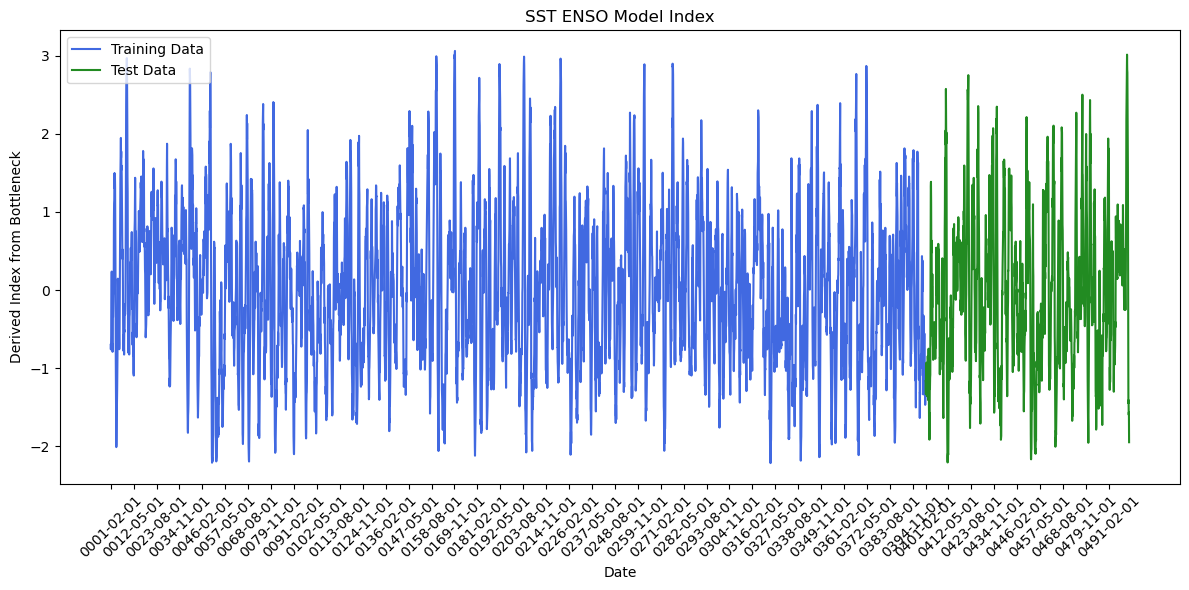

In [148]:
import matplotlib.pyplot as plt

# Select every 3rd point for the training data
train_data_sampled = ensomodel_train_index.iloc[::]
# Select every 3rd point for the test data
test_data_sampled = ensomodel_test_index.iloc[::]

# Plot the sampled training data
plt.figure(figsize=(12, 6))
plt.plot(train_data_sampled['date'], train_data_sampled[0], color='royalblue', label='Training Data')

# Plot the sampled test data
plt.plot(test_data_sampled['date'], test_data_sampled[0], color='forestgreen', label='Test Data')

# Customizing the plot
plt.xlabel('Date')
plt.ylabel('Derived Index from Bottleneck')
plt.title('SST ENSO Model Index')
selected_dates = list(train_data_sampled['date'][::135]) + list(test_data_sampled['date'][::135])
plt.xticks(selected_dates, rotation=45)
plt.legend(loc='upper left')
#plt.xlim(['0401-01-01', '0501-01-01'])
plt.tight_layout()
plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/figures/sst_troppac_0911.png', dpi=350)
plt.show()

## Add ONI Data

In [138]:
oni_e3sm

array([        nan, -0.54011178, -0.42085293, ..., -2.29146361,
       -2.4201982 ,         nan])

In [131]:
#oni_e3sm = oni_e3sm[~np.isnan(oni_e3sm)]

In [139]:
oni_e3sm

array([        nan, -0.54011178, -0.42085293, ..., -2.29146361,
       -2.4201982 ,         nan])

In [140]:
oni_e3sm.shape

(6000,)

In [142]:
import pandas as pd

# Function to create a custom date string representation
def generate_custom_dates(start_year, start_month, periods):
    dates = []
    year, month = start_year, start_month
    for _ in range(periods):
        dates.append(f'{year:04d}-{month:02d}-01')
        month += 1
        if month > 12:
            month = 1
            year += 1
    return dates

# Create string representations of the train dates
oni_dates = pd.DataFrame(oni_e3sm)
train_dates = generate_custom_dates(start_year=1, start_month=2, periods=len(oni_dates))
oni_dates['date'] = train_dates
date = oni_dates['date']

In [143]:
oni_dates

,0,date
0,NaN,0001-02-01
1,-0.540112,0001-03-01
2,-0.420853,0001-04-01
3,-0.225888,0001-05-01
4,-0.037442,0001-06-01
...,...,...
5995,-1.947414,0500-09-01
5996,-2.119579,0500-10-01
5997,-2.291464,0500-11-01
5998,-2.420198,0500-12-01


In [144]:
train_dates[:10]

['0001-02-01',
 '0001-03-01',
 '0001-04-01',
 '0001-05-01',
 '0001-06-01',
 '0001-07-01',
 '0001-08-01',
 '0001-09-01',
 '0001-10-01',
 '0001-11-01']

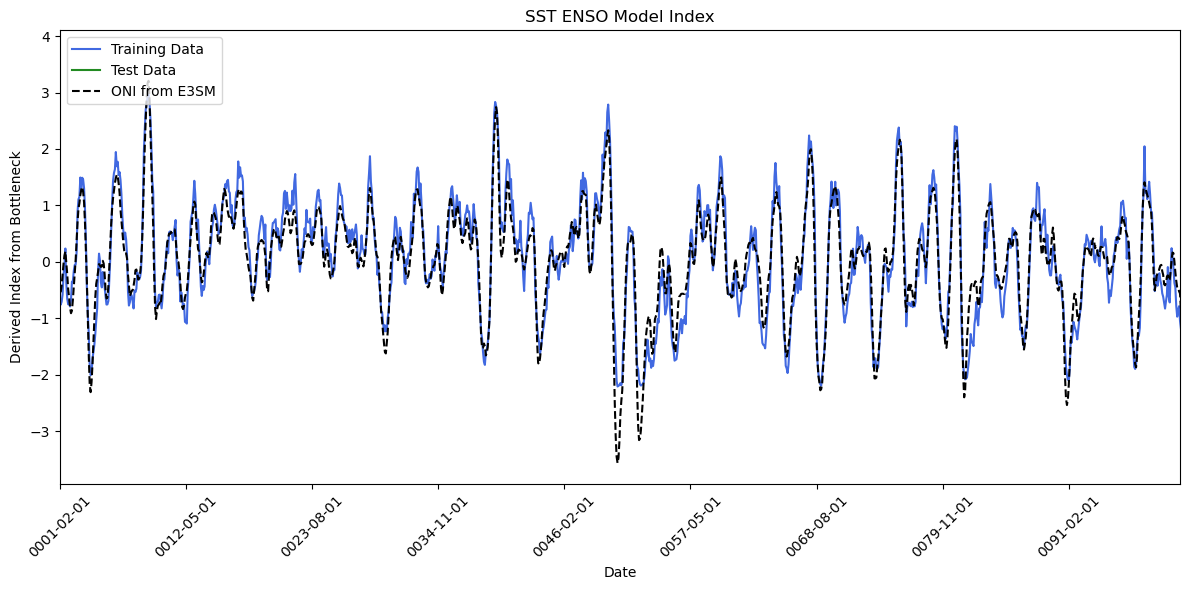

In [150]:
# Select every 3rd point for the training data
train_data_sampled = ensomodel_train_index.iloc[::]
# Select every 3rd point for the test data
test_data_sampled = ensomodel_test_index.iloc[::]

# Plot the sampled training data
plt.figure(figsize=(12, 6))
plt.plot(train_data_sampled['date'], train_data_sampled[0], color='royalblue', label='Training Data')

# Plot the sampled test data
plt.plot(test_data_sampled['date'], test_data_sampled[0], color='forestgreen', label='Test Data')

#plot ONI from e3sm
plt.plot(oni_dates['date'], oni_dates[0], label='ONI from E3SM', color='black', linestyle='--')

# Customizing the plot
plt.xlabel('Date')
plt.ylabel('Derived Index from Bottleneck')
plt.title('SST ENSO Model Index')
selected_dates = list(train_data_sampled['date'][::135]) + list(test_data_sampled['date'][::135])
plt.xticks(selected_dates, rotation=45)
plt.legend(loc='upper left')
plt.xlim(['0001-02-01', '0101-01-01'])
plt.tight_layout()
plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/figures/ssttroppac_oni_train_0911.png', dpi=350)
plt.show()